In [1]:
import cv2
import matplotlib.pyplot as plt

# Open webcam
cap = cv2.VideoCapture(0)

# Read the first frame
ret, frame1 = cap.read()
ret, frame2 = cap.read()

while cap.isOpened():

    # Find difference between two consecutive frames
    diff = cv2.absdiff(frame1, frame2)

    # Convert to grayscale
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    # Blur image
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Threshold image
    _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)

    # Dilate to fill gaps
    dilated = cv2.dilate(thresh, None, iterations=3)

    # Find contours
    contours, _ = cv2.findContours(
        dilated,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw rectangle around moving object
    for contour in contours:

        if cv2.contourArea(contour) < 1000:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            frame1,
            (x, y),
            (x+w, y+h),
            (0,255,0),
            2
        )

        cv2.putText(
            frame1,
            "Movement Detected",
            (10,30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,0,255),
            2
        )

    cv2.imshow("Movement Tracking", frame1)

    # Update frames
    frame1 = frame2
    ret, frame2 = cap.read()

    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

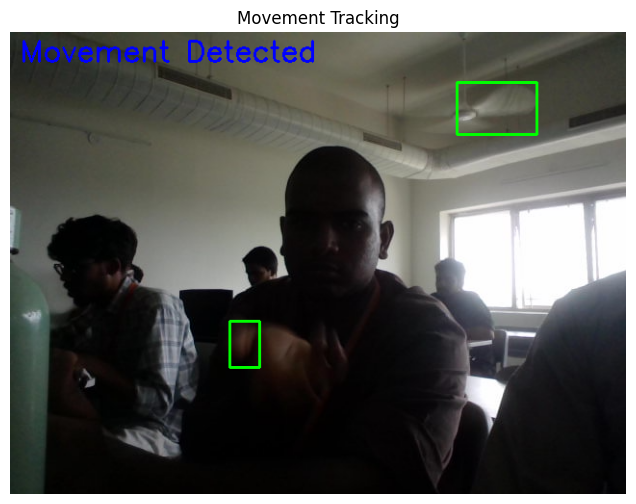

In [4]:
import cv2
import matplotlib.pyplot as plt

# Open webcam
cap = cv2.VideoCapture(0)

# Read two frames
ret, frame1 = cap.read()
ret, frame2 = cap.read()

while True:

    # Difference between frames
    diff = cv2.absdiff(frame1, frame2)

    # Convert to grayscale
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    # Blur
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Threshold
    _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)

    # Dilate
    dilated = cv2.dilate(thresh, None, iterations=3)

    # Find contours
    contours, _ = cv2.findContours(
        dilated,
        cv2.RETR_TREE,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Draw rectangle around movement
    for contour in contours:

        if cv2.contourArea(contour) < 1000:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            frame1,
            (x, y),
            (x+w, y+h),
            (0,255,0),
            2
        )

        cv2.putText(
            frame1,
            "Movement Detected",
            (10,30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,0,0),
            2
        )

    # Display in notebook
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB))
    plt.title("Movement Tracking")
    plt.axis("off")
    plt.show()

    # Update frames
    frame1 = frame2
    ret, frame2 = cap.read()

    # Stop after one iteration
    break

cap.release()